# Expert vs Predicted Affinity Confusion Matrix (Binary: Flag as Relevant)

This notebook replicates `11_affinity_diagnostisc_metrics_adjudicated.ipynb`, but collapses the
three-way `Low` / `Moderate` / `High` affinity levels into a binary **flag-as-relevant** decision:

- `Not Relevant` = Low
- `Relevant` = Moderate or High (collapsed into one class)

This matches a simpler downstream decision ("does this paper get flagged for human review /
shortlisting, or not?"), which may be a more representative test than the full three-way split,
since almost all of the three-way disagreement happens right at the Low/Moderate boundary.

Metrics included:
1. Confusion matrix against expert labels (2x2)
2. Flagging outcomes (operational read: catch-rate, false-alarm rate, missed-relevant rate)
3. Per-class precision / recall / one-vs-rest accuracy
4. Quadratic Weighted Kappa (equivalent to standard Cohen's Kappa for 2 classes) and mean signed error
5. Reliability curve (accuracy vs. ensemble agreement strength)

- Expert source: `calibration_abstract_question_affinities.csv`
- Pred source: `adjudicated_ra_affinities.csv`

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, cohen_kappa_score

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['figure.dpi'] = 120

In [ ]:
repo_root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
import importlib
import sys

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

affinity_metrics = importlib.import_module("src.analysis.affinity_metrics")

expert_root = repo_root / "data" / "processed" / "affinity_calibration"
pred_root = repo_root / "data" / "results" / "affinity_benchmark"

# expert_run_dir_names = ["20260618_Mark_batch1_v4"]
expert_run_dir_names = ["20260727_abstracts_evaluation_template_mark_om_v1"] # benchmark set
# pred_run_dir_names = ["20260724_155639"]
pred_run_dir_names = ["20260726_134607_5"] # 20 promts/benchmark set
expert_input_filename = "calibration_abstract_question_affinities.csv"
pred_input_filename = "adjudicated_ra_affinities.csv"

# Three-way bins used to first classify raw expert/pred values, before collapsing to binary below.
THREE_WAY_LABEL_ORDER = ["Low", "Moderate", "High"]

LABEL_ORDER = ["Not Relevant", "Relevant"]
LABEL_TO_NUM = {"Not Relevant": 0, "Relevant": 1}
NUM_TO_LABEL = {0: "Not Relevant", 1: "Relevant"}

expert_label_col = "Evaluator_Affinity_Level"
pred_score_col = "Final_Affinity"

# Optional metric 5 inputs.
agreement_strength_col = "agreement_mean"
panel_vote_cols = []


def load_table(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        for encoding in ("utf-8-sig", "utf-8", "cp1252", "latin1"):
            try:
                return pd.read_csv(path, encoding=encoding)
            except UnicodeDecodeError:
                continue
        raise UnicodeDecodeError(
            "utf-8", b"", 0, 1, f"Unable to decode CSV file: {path}"
        )
    if path.suffix.lower() in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(f"Unsupported file extension for {path}")

def collect_frames(root: Path, run_dir_names, input_filename: str, source_name: str):
    if isinstance(run_dir_names, (str, Path)):
        run_dir_names = [run_dir_names]

    run_dirs = sorted([p for p in root.iterdir() if p.is_dir()])
    if not run_dirs:
        raise FileNotFoundError(f"No run directories found under {root}")

    selected_run_dirs = [p for p in run_dirs if p.name in {str(x) for x in run_dir_names}]
    if not selected_run_dirs:
        raise FileNotFoundError(f"No matching run directories found for: {run_dir_names}")

    frames = []
    for run_dir in selected_run_dirs:
        input_path = run_dir / input_filename
        if not input_path.exists():
            raise FileNotFoundError(f"Missing file: {input_path}")

        run_df = load_table(input_path)
        run_df["Run_ID"] = run_dir.name
        run_df["Source_Type"] = source_name
        frames.append(run_df)

    return frames, selected_run_dirs

def normalize_level(value):
    # Bucket a raw expert label / affinity score into Low / Moderate / High.
    # Same thresholds as the project adjudication code (scripts/run_affinity_adjudication.py):
    # 1-40 Low, 41-80 Moderate, 81-120 High.
    if pd.isna(value):
        return np.nan

    if isinstance(value, str):
        text = value.strip().lower()
        if text in {"low", "moderate", "high"}:
            return text.capitalize()
        return np.nan

    if isinstance(value, (int, float, np.integer, np.floating)):
        score = float(value)
        if 0 <= score <= 40:
            return "Low"
        if 40 < score <= 80:
            return "Moderate"
        if 80 < score <= 120:
            return "High"

    return np.nan

def collapse_to_binary(three_way_level):
    # Collapse the three-way Low/Moderate/High bucket into a binary flag decision.
    if pd.isna(three_way_level):
        return np.nan
    if three_way_level == "Low":
        return "Not Relevant"
    if three_way_level in ("Moderate", "High"):
        return "Relevant"
    return np.nan

In [ ]:
expert_frames, selected_expert_dirs = collect_frames(
    expert_root, expert_run_dir_names, expert_input_filename, "expert"
)
pred_frames, selected_pred_dirs = collect_frames(
    pred_root, pred_run_dir_names, pred_input_filename, "pred"
)

expert_df = pd.concat(expert_frames, ignore_index=True)
pred_df = pd.concat(pred_frames, ignore_index=True)
merged_df = pd.merge(
    expert_df,
    pred_df,
    on=["Abstract_Index", "RA2025_ID"],
    how="inner",
    suffixes=("_expert", "_pred"),
)

if expert_label_col not in merged_df.columns:
    raise ValueError(f"Could not find expert label column '{expert_label_col}'.")
if pred_score_col not in merged_df.columns:
    raise ValueError(f"Could not find pred score column '{pred_score_col}'.")

merged_df["expert_level_3way"] = merged_df[expert_label_col].apply(normalize_level)
merged_df["pred_level_3way"] = merged_df[pred_score_col].apply(normalize_level)

merged_df["expert_level"] = merged_df["expert_level_3way"].apply(collapse_to_binary)
merged_df["pred_level"] = merged_df["pred_level_3way"].apply(collapse_to_binary)

clean_df = merged_df.dropna(subset=["expert_level", "pred_level"]).copy()
clean_df["expert_num"] = clean_df["expert_level"].map(LABEL_TO_NUM).astype(int)
clean_df["pred_num"] = clean_df["pred_level"].map(LABEL_TO_NUM).astype(int)

print("Expert run directories:", [p.name for p in selected_expert_dirs])
print("Pred run directories:", [p.name for p in selected_pred_dirs])
print("Expert rows loaded:", len(expert_df))
print("Pred rows loaded:", len(pred_df))
print("Rows after inner merge:", len(merged_df))
print("Rows after label cleaning:", len(clean_df))
print(f'Unique abstract indices: {clean_df.Abstract_Index.unique().size:,}')

print("Three-way expert label distribution (for reference):")
display(clean_df["expert_level_3way"].value_counts().reindex(THREE_WAY_LABEL_ORDER, fill_value=0).to_frame("count"))

print("Binary expert label distribution:")
display(clean_df["expert_level"].value_counts().reindex(LABEL_ORDER, fill_value=0).to_frame("count"))
print("Binary pred label distribution:")
display(clean_df["pred_level"].value_counts().reindex(LABEL_ORDER, fill_value=0).to_frame("count"))
display(clean_df[["Abstract_Index", "RA2025_ID", expert_label_col, pred_score_col, "expert_level", "pred_level"]].head(10))

Expert run directories: ['20260727_abstracts_evaluation_template_mark_om_v1']
Pred run directories: ['20260726_134607_1']
Expert rows loaded: 602
Pred rows loaded: 5040
Rows after inner merge: 602
Rows after label cleaning: 602
Unique abstract indices: 91
Three-way expert label distribution (for reference):


,count
expert_level_3way,
Low,438
Moderate,137
High,27


Binary expert label distribution:


,count
expert_level,
Not Relevant,438
Relevant,164


Binary pred label distribution:


,count
pred_level,
Not Relevant,335
Relevant,267


,Abstract_Index,RA2025_ID,Evaluator_Affinity_Level,Final_Affinity,expert_level,pred_level
0,10.1109/TPWRS.2023.3256642,28,Low,22.0,Not Relevant,Not Relevant
1,10.1109/TPWRS.2023.3256642,29,Low,22.0,Not Relevant,Not Relevant
2,10.1109/TPWRS.2023.3256642,30,Low,28.0,Not Relevant,Not Relevant
3,10.1109/TPWRS.2023.3256642,31,Low,20.0,Not Relevant,Not Relevant
4,10.1109/TPWRS.2023.3256642,32,Low,8.0,Not Relevant,Not Relevant
5,10.1109/TPWRS.2023.3256642,33,Low,24.0,Not Relevant,Not Relevant
6,10.1109/TPWRS.2023.3256642,34,Low,14.0,Not Relevant,Not Relevant
7,10.1109/TPWRS.2023.3256642,35,Moderate,46.0,Relevant,Relevant
8,10.1109/TPWRS.2023.3256642,36,Moderate,65.4,Relevant,Relevant
9,10.1109/TPWRS.2023.3243669,37,Moderate,82.0,Relevant,Relevant


,Pred Not Relevant,Pred Relevant
Expert Not Relevant,299,139
Expert Relevant,36,128


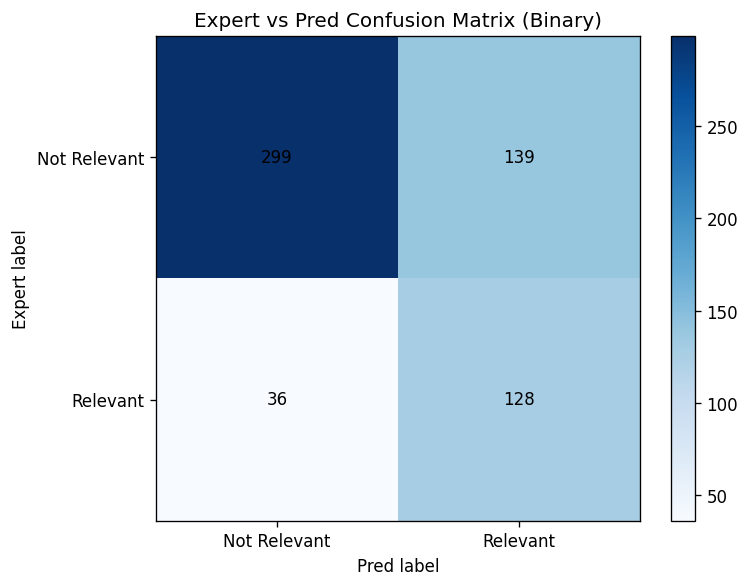

In [ ]:
y_true = clean_df["expert_num"].to_numpy()
y_pred = clean_df["pred_num"].to_numpy()

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=[f"Expert {label}" for label in LABEL_ORDER],
    columns=[f"Pred {label}" for label in LABEL_ORDER],
)
display(cm_df)

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(LABEL_ORDER)
ax.set_yticklabels(LABEL_ORDER)
ax.set_xlabel("Pred label")
ax.set_ylabel("Expert label")
ax.set_title("Expert vs Pred Confusion Matrix (Binary)")

for row in range(cm.shape[0]):
    for col in range(cm.shape[1]):
        ax.text(col, row, str(cm[row, col]), ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Flagging Outcomes (operational read)

Framed as an actual "flag as relevant" decision: of papers the expert says are truly Relevant, how
many get caught vs. silently missed; of papers the system flags, how many are actually Relevant.

In [ ]:
tn, fp, fn, tp = cm.ravel()

catch_rate = tp / (tp + fn) if (tp + fn) else float("nan")           # recall on Relevant
miss_rate = fn / (tp + fn) if (tp + fn) else float("nan")            # 1 - catch_rate
precision_flagged = tp / (tp + fp) if (tp + fp) else float("nan")    # precision on Relevant
false_alarm_rate = fp / (fp + tn) if (fp + tn) else float("nan")     # 1 - specificity

flagging_df = pd.DataFrame({
    "Metric": [
        "Relevant papers correctly flagged (catch-rate / recall)",
        "Relevant papers missed (silently dropped)",
        "Flagged papers that are truly Relevant (precision)",
        "Not-Relevant papers wrongly flagged (false-alarm rate)",
    ],
    "Count": [tp, fn, tp, fp],
    "Rate": [catch_rate, miss_rate, precision_flagged, false_alarm_rate],
})
display(flagging_df)

,Metric,Count,Rate
0,Relevant papers correctly flagged (catch-rate ...,128,0.780488
1,Relevant papers missed (silently dropped),36,0.219512
2,Flagged papers that are truly Relevant (precis...,128,0.479401
3,Not-Relevant papers wrongly flagged (false-ala...,139,0.317352


## Metric 2: Per-Class Metrics

In [ ]:
class_metrics_df = affinity_metrics.build_affinity_class_metrics(
    y_true,
    y_pred,
    labels=list(LABEL_TO_NUM.values()),
    class_names=LABEL_ORDER,
)

display(
    class_metrics_df[[
        'Class',
        'Support',
        'Precision',
        'Recall',
        'One_vs_Rest_Accuracy',
    ]]
)

,Class,Support,Precision,Recall,One_vs_Rest_Accuracy
0,Not Relevant,438,0.892537,0.682648,0.709302
1,Relevant,164,0.479401,0.780488,0.709302


## Metric 3 and 4: Quadratic Weighted Kappa and Mean Signed Error

In [ ]:
qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
mean_signed_error = float(np.mean(y_pred - y_true))
accuracy = float(np.mean(y_pred == y_true))

print(f'Accuracy                 = {accuracy:.4f}')
print(f'Quadratic Weighted Kappa = {qwk:.4f}  (equivalent to standard Cohen\'s Kappa for 2 classes)')
print(f'Mean signed error        = {mean_signed_error:.4f}')

Accuracy                 = 0.7093
Quadratic Weighted Kappa = 0.3871  (equivalent to standard Cohen's Kappa for 2 classes)
Mean signed error        = 0.1711


## Metric 5: Reliability Curve

/tmp/ipykernel_8043/3186463333.py:54: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: pd.Series({
/tmp/ipykernel_8043/3186463333.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: pd.Series({


,agreement_strength,n_cases,accuracy
0,0.333333,39.0,0.435897
1,0.500000,367.0,0.664850
2,1.000000,196.0,0.846939


,agreement_strength,expert_level,n_cases,accuracy
0,0.333333,Not Relevant,22.0,0.045455
2,0.500000,Not Relevant,251.0,0.609562
4,1.000000,Not Relevant,165.0,0.878788
1,0.333333,Relevant,17.0,0.941176
3,0.500000,Relevant,116.0,0.784483
5,1.000000,Relevant,31.0,0.677419


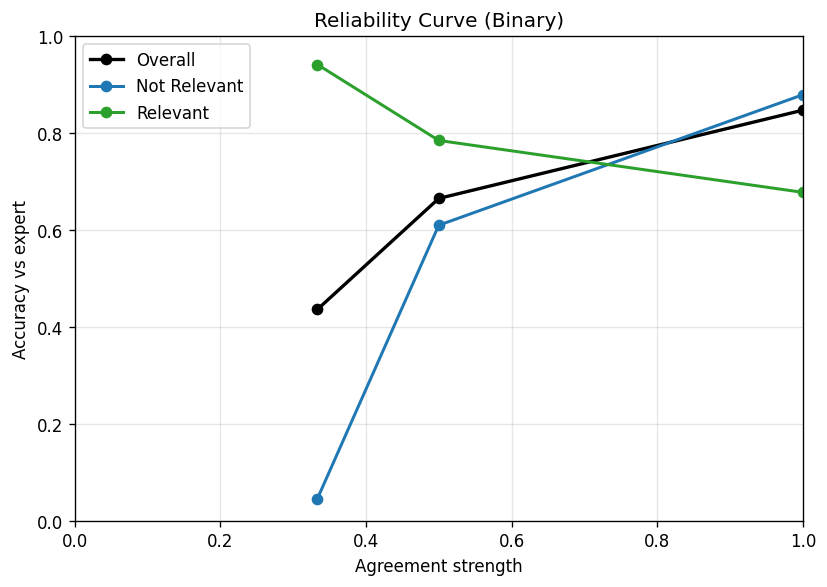

In [ ]:
reliability_df = None
reliability_by_level_df = True


def compute_agreement_strength(row, pred_col_name, vote_cols):
    final_label = collapse_to_binary(normalize_level(row[pred_col_name]))
    votes = row[vote_cols].dropna()
    if len(votes) == 0:
        return np.nan
    votes_clean = votes.map(lambda v: collapse_to_binary(normalize_level(v)))
    votes_clean = votes_clean.dropna()
    if len(votes_clean) == 0 or pd.isna(final_label):
        return np.nan
    return float((votes_clean == final_label).sum() / len(votes_clean))


def groupwise_one_vs_rest_accuracy(group_df):
    return affinity_metrics.aggregate_one_vs_rest_accuracy(
        group_df['expert_num'],
        group_df['pred_num'],
        labels=list(LABEL_TO_NUM.values()),
        class_names=LABEL_ORDER,
    )

if agreement_strength_col is not None and agreement_strength_col in clean_df.columns:
    work = clean_df.copy()
    work['agreement_strength'] = pd.to_numeric(work[agreement_strength_col], errors='coerce')
elif panel_vote_cols:
    missing_votes = [c for c in panel_vote_cols if c not in clean_df.columns]
    if missing_votes:
        print(f'Skipping reliability curve: missing panel vote columns: {missing_votes}')
        work = None
    else:
        work = clean_df.copy()
        work['agreement_strength'] = work.apply(
            compute_agreement_strength, axis=1, args=("pred_level", panel_vote_cols)
        )
else:
    print('Skipping reliability curve: set agreement_strength_col or panel_vote_cols to compute it.')
    work = None

if work is not None:
    rel = work.dropna(subset=['agreement_strength']).copy()
    rel = rel[(rel['agreement_strength'] >= 0.0) & (rel['agreement_strength'] <= 1.0)].copy()

    if len(rel) == 0:
        print('Skipping reliability curve: no usable agreement strength values in [0, 1].')
    else:
        rel['agreement_strength'] = rel['agreement_strength'].astype(float)
        rel['is_correct'] = (rel['pred_num'] == rel['expert_num']).astype(int)

        reliability_df = (
            rel.groupby('agreement_strength', observed=False)
            .apply(lambda group: pd.Series({
                'n_cases': len(group),
                'accuracy': groupwise_one_vs_rest_accuracy(group),
            }))
            .reset_index()
            .sort_values('agreement_strength')
        )

        reliability_by_level_df = (
            rel.groupby(['agreement_strength', 'expert_level'], observed=False)
            .apply(lambda group: pd.Series({
                'n_cases': len(group),
                'accuracy': groupwise_one_vs_rest_accuracy(group),
            }))
            .reset_index()
            .sort_values(['expert_level', 'agreement_strength'])
        )

        display(reliability_df[['agreement_strength', 'n_cases', 'accuracy']])
        display(reliability_by_level_df[['agreement_strength', 'expert_level', 'n_cases', 'accuracy']])

        fig, ax = plt.subplots()
        ax.plot(
            reliability_df['agreement_strength'],
            reliability_df['accuracy'],
            marker='o',
            color='black',
            linewidth=2,
            label='Overall',
        )

        level_display_order = ['Not Relevant', 'Relevant']
        level_colors = {'Not Relevant': '#1f77b4', 'Relevant': '#2ca02c'}

        for level in level_display_order:
            level_df = reliability_by_level_df[reliability_by_level_df['expert_level'] == level]
            if level_df.empty:
                continue
            ax.plot(
                level_df['agreement_strength'],
                level_df['accuracy'],
                marker='o',
                linewidth=1.8,
                label=level,
                color=level_colors[level],
            )

        ax.set_xlabel('Agreement strength')
        ax.set_ylabel('Accuracy vs expert')
        ax.set_title('Reliability Curve (Binary)')
        ax.set_ylim(0, 1)
        ax.set_xlim(0, 1)
        ax.grid(alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

## Notes

This notebook mirrors `11_affinity_diagnostisc_metrics_adjudicated.ipynb`, with `Moderate` and `High`
collapsed into a single `Relevant` class and `Low` kept as `Not Relevant`. Change `pred_run_dir_names`
in the setup cell to compare a different prediction run; the underlying three-way bucketing
(`normalize_level`) is unchanged from the source notebook, so results stay directly comparable.